![alt text](src/img/Portada.png)
# Modelado de Tasación Automotriz: Mercado Alemán (AutoScout24)

### Paso 1: Entendiendo el problema y carga de datos

El objetivo es construir un modelo de regresión capaz de predecir el precio de vehículos de ocasión en el mercado alemán utilizando el dataset de AutoScout24. Se busca minimizar el error absoluto medio (MAE) para ofrecer tasaciones realistas.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')


In [2]:
# 1.1. Carga del dataset procesado
# El archivo .pkl contiene los conjuntos de entrenamiento y prueba ya limpios y codificados
X_train, X_test, y_train, y_test = joblib.load('src/data_sample/processed/datos_procesados.pkl')

# 1.2. Eliminación de redundancias (Multicolinealidad)
# El análisis de correlación de Pearson mostró una relación de -1.00 entre 'año' y 'antigüedad'.
# Mantenemos 'antigüedad' por ser más intuitiva para el modelo y eliminamos 'año'.
X_train = X_train.drop(columns=['año'])
X_test = X_test.drop(columns=['año'])

print(f"Datos cargados y filtrados con éxito.")
print(f"Variables finales para el modelo: {X_train.columns.tolist()}")
print(f"Tamaño del set de entrenamiento: {X_train.shape[0]} registros")

Datos cargados y filtrados con éxito.
Variables finales para el modelo: ['kilometraje (km)', 'marca', 'modelo', 'combustible', 'transmisión', 'tipo de oferta', 'caballos de fuerza (CV)', 'antigüedad', 'km_anuales', 'gama_marca']
Tamaño del set de entrenamiento: 35157 registros


### Paso 2: Selección del modelo final (Gradient Boosting)

Tras una fase de experimentación (benchmarking), se determinó que el algoritmo de Gradient Boosting ofrece el mejor equilibrio entre precisión y generalización. Procedemos a su entrenamiento con los hiperparámetros optimizados.

In [3]:
# Definimos el modelo con los mejores parámetros encontrados
best_gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    random_state=42
)

# Entrenamiento del modelo
best_gb.fit(X_train, y_train)
print("Modelo Gradient Boosting entrenado con éxito.")

Modelo Gradient Boosting entrenado con éxito.


### Paso 3: Evaluación contra test

Evaluamos el rendimiento del modelo utilizando el conjunto de datos de prueba (datos que el modelo nunca ha visto) para medir su capacidad de predicción real.

In [4]:
# Realizamos las predicciones
y_pred = best_gb.predict(X_test)

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Métricas de Evaluación ---")
print(f"MAE (Error Medio Absoluto): {mae:.2f} €")
print(f"RMSE (Error Cuadrático Medio): {rmse:.2f} €")
print(f"R2 Score: {r2:.4f}")

--- Métricas de Evaluación ---
MAE (Error Medio Absoluto): 1773.92 €
RMSE (Error Cuadrático Medio): 5559.19 €
R2 Score: 0.8919


### Paso 4: Visualización de resultados

Generamos un Scatter Plot de valores reales frente a predicciones para visualizar la "puntería" del modelo. La línea roja representa la predicción perfecta.

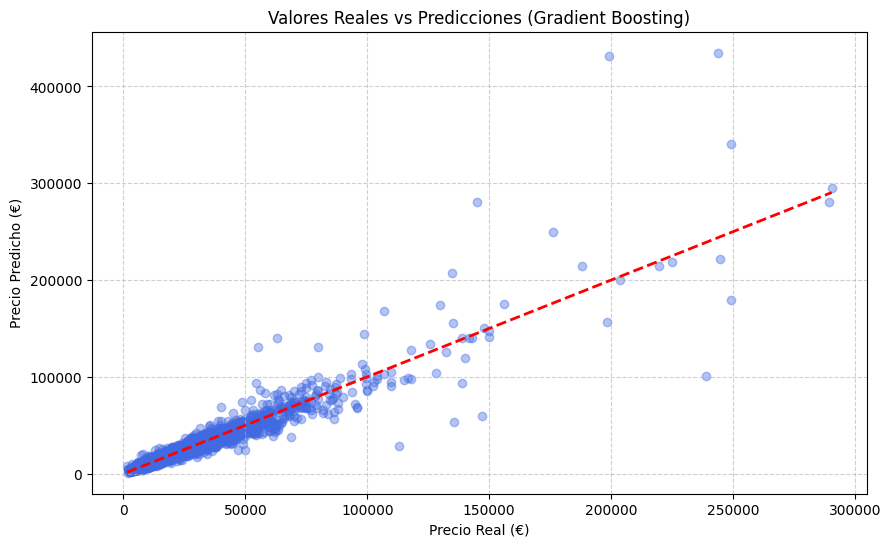

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Valores Reales vs Predicciones (Gradient Boosting)')
plt.xlabel('Precio Real (€)')
plt.ylabel('Precio Predicho (€)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Paso 5: Importancia de las variables
Analizamos qué factores influyen más en la determinación del precio según el modelo entrenado.

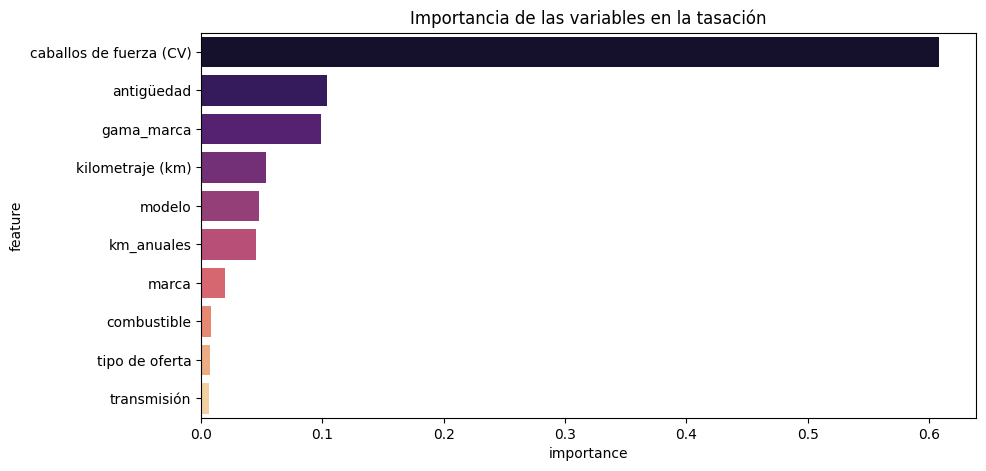

In [6]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_gb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=importances, palette='magma')
plt.title('Importancia de las variables en la tasación')
plt.show()

### Paso 6: Persistencia del modelo
Para finalizar, guardamos el modelo optimizado en formato .joblib dentro del directorio src/models para su posterior puesta en producción.

In [7]:
# Crear el directorio si no existe
os.makedirs('src/models', exist_ok=True)

# Guardar el modelo
ruta_guardado = 'src/models/modelo_tasacion_final.joblib'
joblib.dump(best_gb, ruta_guardado)

print(f"Proceso finalizado. Modelo grabado en: {ruta_guardado}")

Proceso finalizado. Modelo grabado en: src/models/modelo_tasacion_final.joblib
